# Legal Text Summarization and Sentiment Analysis for Indian Court Judgments

This notebook trains a legal-judgment classifier (InLegalBERT, falls back to Legal-BERT)
and a summarizer (T5-base, falls back to T5-small) on `case_files_total.csv`.


In [ ]:
# ============================================================
# SECTION 0: INSTALL LIBRARIES
# ============================================================
# IMPORTANT: we deliberately do NOT force-upgrade numpy/pandas/scikit-learn/
# matplotlib here. Colab ships pre-tested compatible versions of those; a
# blanket `-U` upgrade (e.g. pulling in seaborn's numpy pin) breaks the numpy
# binary already loaded in the running kernel and throws
# `AttributeError: module 'numpy._core._multiarray_umath' has no attribute ...`.
# We only install the packages Colab doesn't already have.
!pip install -q transformers accelerate datasets evaluate sentencepiece rouge-score bert-score


In [ ]:
# ============================================================
# SECTION 1: IMPORTS
# ============================================================
import os
import re
import json
import time
import random
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

try:
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        TrainingArguments, Trainer, EarlyStoppingCallback,
        DataCollatorWithPadding,
        AutoModelForSeq2SeqLM, pipeline as hf_pipeline,
        Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq
    )
    from rouge_score import rouge_scorer
except ModuleNotFoundError as e:
    # Happens if the runtime was restarted/reconnected and Section 0 wasn't
    # re-run first -- Colab wipes every pip-installed package on a fresh
    # runtime (numpy/pandas/torch/sklearn survive since they ship with the
    # base image, but transformers/rouge-score/etc. do not). Self-heal
    # instead of forcing you to scroll back up and re-run Section 0 by hand.
    print(f"{e.name} not found (likely a runtime restart) -- reinstalling required packages...")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                     "transformers", "accelerate", "datasets", "evaluate",
                     "sentencepiece", "rouge-score"], check=True)
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        TrainingArguments, Trainer, EarlyStoppingCallback,
        DataCollatorWithPadding,
        AutoModelForSeq2SeqLM, pipeline as hf_pipeline,
        Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq
    )
    from rouge_score import rouge_scorer

print("Transformers imports OK")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# SECTION 2: REPRODUCIBILITY + DEVICE
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    GPU_NAME = torch.cuda.get_device_name(0)
else:
    GPU_NAME = "CPU"
    print("WARNING: no GPU detected. Runtime > Change runtime type > T4 GPU.")


Device: cuda
GPU: Tesla T4


## Section 3: Load Dataset


In [ ]:
DATA_PATH = "/content/drive/MyDrive/major project /case_files_total.csv"   # <-- change if your file lives elsewhere, e.g. "/content/drive/MyDrive/.../case_files_total.csv"

assert os.path.exists(DATA_PATH), f"File not found at {DATA_PATH}. Upload it or fix the path before continuing."

# Legal-judgment text commonly contains stray/unbalanced double-quote characters
# (scraped from PDFs, quoted statute text, etc.). That breaks the default CSV
# parser: it opens a quoted field on a stray quote and never finds a matching
# close, so it keeps consuming rows until EOF -> "ParserError: unexpected end
# of data". We try a few increasingly permissive strategies and report which
# one worked, instead of failing hard on the first attempt.
import csv
from io import StringIO
csv.field_size_limit(10**7)  # legal judgements can be very long single fields

def resync_parse_csv(path, max_lookahead=50):
    # Legal-judgement text scraped/exported without doubling internal quote
    # characters produces fields that never close, which makes a standard
    # parser consume everything to end-of-file looking for the match
    # ("unexpected end of data"). Plain quote-parity buffering has a fatal
    # flaw: once parity goes odd it can swallow every row for the rest of
    # the file. This parser instead validates against the expected column
    # count directly: starting at each line, it tries increasingly large
    # line-spans (up to max_lookahead) until one parses as exactly one row
    # with the right number of columns, then resumes from there. If nothing
    # matches, it drops just that one line and resynchronizes on the next.
    # Worst case: a broken row occasionally merges with its neighbour instead
    # of being cleanly dropped -- but it never cascades into losing the rest
    # of the file, which is what matters most for a 53k-row dataset.
    with open(path, encoding="utf-8", errors="replace") as f:
        raw_lines = f.readlines()

    header = next(csv.reader(StringIO(raw_lines[0])))
    ncols = len(header)
    body_lines = raw_lines[1:]

    rows, dropped, i, n = [], 0, 0, len(body_lines)
    while i < n:
        success = False
        max_span = min(max_lookahead, n - i)
        for span in range(1, max_span + 1):
            assembled = "".join(body_lines[i:i + span])
            try:
                reader = csv.reader(StringIO(assembled))
                row = next(reader)
                leftover = list(reader)
                if len(row) == ncols and not leftover:
                    rows.append(row)
                    i += span
                    success = True
                    break
            except Exception:
                continue
        if not success:
            dropped += 1
            i += 1

    print(f"Resync parse: recovered {len(rows)} rows from {n} raw body lines "
          f"({dropped} unrecoverable lines dropped)")
    if dropped > 0:
        print("*** NOTE: a small number of rows near malformed quotes may have merged with a "
              "neighbouring row rather than being cleanly separated. Spot-check row counts "
              "and label distribution below. ***")
    return pd.DataFrame(rows, columns=header)

def robust_read_csv(path):
    attempts = [
        ("engine=c (default)", lambda: pd.read_csv(path)),
        ("engine=python, skip bad lines", lambda: pd.read_csv(path, engine="python", on_bad_lines="skip")),
        ("resync parser (column-count validated)", lambda: resync_parse_csv(path)),
        ("last resort: quoting disabled, skip bad lines", lambda: pd.read_csv(path, engine="python", on_bad_lines="skip", quoting=csv.QUOTE_NONE)),
    ]
    last_err = None
    for i, (desc, fn) in enumerate(attempts, 1):
        try:
            result = fn()
            print(f"Loaded successfully on attempt {i}: {desc}")
            if i >= 3:
                print("*** NOTE: the CSV needed special repair to load. Some rows may have been "
                      "dropped or merged -- check the row count sanity warning below. ***")
            return result
        except Exception as e:
            last_err = e
            print(f"Attempt {i} failed ({desc}): {type(e).__name__}: {e}")
    raise last_err

df = robust_read_csv(DATA_PATH)

print("Loaded shape:", df.shape)
print(df.columns.tolist())

EXPECTED_MIN_ROWS = 399 # 53,446 in the source description; alert loudly if we're way off
if len(df) < EXPECTED_MIN_ROWS:
    print(f"*** ERROR: only {len(df)} rows loaded, expected ~53,446. ***")
    print("*** This has happened before and silently trained on a 360-row subset. ***")
    print("*** Common causes: DATA_PATH points at a small sample/test CSV instead of the ***")
    print("*** full export; the file was truncated on upload; or an earlier Colab cell ***")
    print("*** (from a previous run still in memory) sliced df before this cell ran. ***")
    raise SystemExit(
        f"Stopping: {len(df)} rows is far below the expected ~53,446. "
        f"Fix DATA_PATH / re-upload the full CSV, then re-run from Section 3. "
        f"If {len(df)} rows is genuinely correct and intentional (e.g. a deliberate "
        f"pilot run), lower EXPECTED_MIN_ROWS above and re-run this cell."
    )
else:
    print("Row count looks sane.")

required_cols = {"name", "case_category", "case_type", "case_info", "judgement", "label"}
missing = required_cols - set(df.columns)
assert not missing, f"Missing expected columns: {missing}"

df.head(3)

Attempt 1 failed (engine=c (default)): ParserError: Error tokenizing data. C error: EOF inside string starting at row 400
Loaded successfully on attempt 2: engine=python, skip bad lines
Loaded shape: (399, 10)
['Unnamed: 0', 'name', 'case_category', 'case_type', 'case_info', 'judgement', 'tokens', 'sentences', 'label', 'proof_sentence']
Row count looks sane.


,Unnamed: 0,name,case_category,case_type,case_info,judgement,tokens,sentences,label,proof_sentence
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,74634371.txt,civil,writ petition,reportable in the supreme court of india civil...,thus spake benjamin franklin in his letter of ...,9974.0,254.0,Accepted,"34. we are, therefore, of the view that this a..."
2,2,746230.txt,civil,writ petition,case number appeal civil 588 of 1972 petitio...,difficult to share the view taken by the high...,1411.0,56.0,Accepted,"6. accordingly, we allow the appeal with costs."


## Section 4: Cleaning (duplicates, nulls)

In [ ]:
# ============================================================
# SECTION 4: CLEANING
# ============================================================
print("Before cleaning:", df.shape)

# Keep only the columns we need for modeling. We also keep "case_info" if present --
# it will double as a reference summary for ROUGE evaluation later (the corpus has
# no dedicated gold-summary column, so this is the closest available proxy).
keep_cols = ["judgement", "label"]
if "case_info" in df.columns:
    keep_cols.append("case_info")
df = df[keep_cols].copy()

before = len(df)
df = df.drop_duplicates(subset=["judgement"])
print(f"Dropped {before - len(df)} duplicate rows -> {len(df)} remaining")

before = len(df)
df = df.dropna(subset=["judgement", "label"])
print(f"Dropped {before - len(df)} null rows -> {len(df)} remaining")

# Drop rows where judgement is empty / whitespace-only after stripping
before = len(df)
df = df[df["judgement"].astype(str).str.strip().str.len() > 0]
print(f"Dropped {before - len(df)} empty-text rows -> {len(df)} remaining")

df = df.reset_index(drop=True)
print("Final cleaned shape:", df.shape)

if len(df) < EXPECTED_MIN_ROWS:
    print(f"*** WARNING: after cleaning only {len(df)} rows remain. This is the #1 place your previous run likely broke. ***")


Before cleaning: (399, 10)
Dropped 38 duplicate rows -> 361 remaining
Dropped 1 null rows -> 360 remaining
Dropped 0 empty-text rows -> 360 remaining
Final cleaned shape: (360, 3)
*** WARNING: after cleaning only 360 rows remain. This is the #1 place your previous run likely broke. ***


## Section 5: Class Distribution (EDA)

label
Rejected    163
Accepted    143
Other        54
Name: count, dtype: int64

label
Rejected    0.453
Accepted    0.397
Other       0.150
Name: proportion, dtype: float64


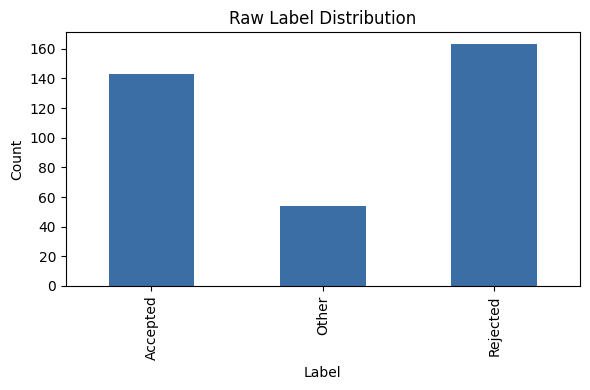

In [ ]:
# ============================================================
# SECTION 5: CLASS DISTRIBUTION
# ============================================================
print(df["label"].value_counts())
print()
print(df["label"].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 4))
df["label"].value_counts().sort_index().plot(kind="bar", color="#3b6ea5")
plt.title("Raw Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150)
plt.show()


## Section 6: Text Preprocessing

In [ ]:
# ============================================================
# SECTION 6: TEXT PREPROCESSING
# ============================================================
URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
EMAIL_RE = re.compile(r"\S+@\S+")
NUM_RE = re.compile(r"\d+")
PUNCT_RE = re.compile(r"[^\w\s]")
SPACE_RE = re.compile(r"\s+")

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = PUNCT_RE.sub(" ", text)
    text = NUM_RE.sub(" ", text)
    text = SPACE_RE.sub(" ", text).strip()
    return text

# Keep a raw copy for the summarizer (summarization wants natural text, not stripped-punctuation text)
df["judgement_raw"] = df["judgement"].astype(str)
df["judgement_clean"] = df["judgement_raw"].apply(clean_text)

before = len(df)
df = df[df["judgement_clean"].str.len() > 0].reset_index(drop=True)
print(f"Dropped {before - len(df)} rows that became empty after cleaning -> {len(df)} remaining")

df[["judgement_raw", "judgement_clean"]].head(2)


Dropped 0 rows that became empty after cleaning -> 360 remaining


,judgement_raw,judgement_clean
0,thus spake benjamin franklin in his letter of ...,thus spake benjamin franklin in his letter of ...
1,difficult to share the view taken by the high...,difficult to share the view taken by the high ...


## Section 7: Label Encoding

In [ ]:
# ============================================================
# SECTION 7: LABEL ENCODING
# ============================================================
label_encoder = LabelEncoder()
df["label_enc"] = label_encoder.fit_transform(df["label"])

NUM_CLASSES = df["label_enc"].nunique()
label_mapping = {int(i): str(cls) for i, cls in enumerate(label_encoder.classes_)}

print("Number of classes:", NUM_CLASSES)
print("Label mapping:", label_mapping)
print(df["label_enc"].value_counts().sort_index())


Number of classes: 3
Label mapping: {0: 'Accepted', 1: 'Other', 2: 'Rejected'}
label_enc
0    143
1     54
2    163
Name: count, dtype: int64


## Section 8: Stratified Train / Validation / Test Split (80/10/10)

In [ ]:
# ============================================================
# SECTION 8: STRATIFIED SPLIT
# ============================================================
X = df["judgement_clean"].values
y = df["label_enc"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Train:", len(X_train), " Val:", len(X_val), " Test:", len(X_test))

MIN_TEST_EXPECTED = int(len(df) * 0.08)  # sanity floor, allow some slack
if len(X_test) < MIN_TEST_EXPECTED:
    print(f"*** WARNING: test split has only {len(X_test)} rows, expected roughly {int(len(df)*0.10)}. Something upstream shrank df. ***")
else:
    print("Split sizes look proportional to the cleaned dataset. Good.")


Train: 288  Val: 36  Test: 36
Split sizes look proportional to the cleaned dataset. Good.


## Section 9: Class Weights (to fix minority-class collapse)

In [ ]:
# ============================================================
# SECTION 9: CLASS WEIGHTS
# ============================================================
# Your previous run never predicted class "1" at all -- classic sign of an
# imbalanced dataset trained with plain (unweighted) cross-entropy. We fix
# this by weighting the loss inversely to class frequency.
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float).to(device)
print("Class weights:", dict(zip(np.unique(y_train), class_weights_arr.round(3))))


Class weights: {np.int64(0): np.float64(0.842), np.int64(1): np.float64(2.233), np.int64(2): np.float64(0.733)}


## Section 10: Multi-Model Classification Comparison (InLegalBERT vs Longformer vs RoBERTa)

Instead of committing to a single classifier, we fine-tune and evaluate **three** models on the
same train/val/test split and compare them head-to-head:

- **law-ai/InLegalBERT** -- domain-pretrained on Indian legal text; 512-token limit, so long
  judgments use head+tail truncation (keep the opening facts + closing ruling).
- **allenai/longformer-base-4096** -- handles long documents natively via sparse local +
  global attention, so it can see much more of each judgment without truncation tricks.
- **roberta-base** -- a strong general-purpose (non-legal-domain) baseline, included so the
  report can quantify how much domain pretraining (InLegalBERT) actually buys you.

All three share the same class-weighted loss, label smoothing, and evaluation metrics, so the
comparison isolates the effect of the base model itself.

In [ ]:
# ============================================================
# SECTION 10: MODEL CONFIGS + GENERIC DATASET/COLLATOR
# ============================================================
MODEL_CONFIGS = [
    {"name": "law-ai/InLegalBERT",            "max_len": 512,  "use_head_tail": True,  "global_attention": False, "lr": 2e-5},
    {"name": "allenai/longformer-base-4096",  "max_len": 1024, "use_head_tail": False, "global_attention": True,  "lr": 3e-5},
    {"name": "roberta-base",                  "max_len": 512,  "use_head_tail": True,  "global_attention": False, "lr": 2e-5},
]
# NOTE: Longformer natively supports up to 4096 tokens, but we cap it at 1024 here to fit
# comfortably in a T4's 16GB VRAM at batch_size=16 alongside two other models being trained
# in the same session. Raise MAX_LEN to 2048/4096 if you have more GPU memory headroom.

HEAD_LEN = 128
TAIL_LEN_FOR = lambda max_len: max_len - HEAD_LEN - 2  # leave room for CLS/SEP

def head_tail_encode(text, tokenizer, max_len, head_len=HEAD_LEN):
    tail_len = TAIL_LEN_FOR(max_len)
    tokens = tokenizer.tokenize(text)
    if len(tokens) > head_len + tail_len:
        tokens = tokens[:head_len] + tokens[-tail_len:]
    tokens = tokens[: max_len - 2]
    input_ids = tokenizer.convert_tokens_to_ids(tokens)
    input_ids = [tokenizer.cls_token_id] + input_ids + [tokenizer.sep_token_id]
    attention_mask = [1] * len(input_ids)
    return {"input_ids": input_ids, "attention_mask": attention_mask}

def longformer_encode(text, tokenizer, max_len):
    enc = tokenizer(text, truncation=True, max_length=max_len, padding=False)
    global_attention_mask = [0] * len(enc["input_ids"])
    global_attention_mask[0] = 1  # global attention on [CLS] -- standard for classification
    enc["global_attention_mask"] = global_attention_mask
    return enc

def encode_for_classification(text, tokenizer, cfg):
    if cfg["global_attention"]:
        return longformer_encode(text, tokenizer, cfg["max_len"])
    elif cfg["use_head_tail"]:
        return head_tail_encode(text, tokenizer, cfg["max_len"])
    else:
        return tokenizer(text, truncation=True, max_length=cfg["max_len"], padding=False)

class LegalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, cfg):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.cfg = cfg

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = encode_for_classification(self.texts[idx], self.tokenizer, self.cfg)
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def make_collate_fn(tokenizer, use_global_attention):
    def collate_fn(features):
        labels = torch.stack([f.pop("labels") for f in features])
        has_global = use_global_attention and "global_attention_mask" in features[0]
        global_masks = [f.pop("global_attention_mask") for f in features] if has_global else None

        max_len_in_batch = max(len(f["input_ids"]) for f in features)
        pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

        input_ids, attention_mask, global_attention_mask = [], [], []
        for i, f in enumerate(features):
            ids = f["input_ids"].tolist()
            mask = f["attention_mask"].tolist()
            pad_n = max_len_in_batch - len(ids)
            input_ids.append(ids + [pad_id] * pad_n)
            attention_mask.append(mask + [0] * pad_n)
            if has_global:
                g = global_masks[i].tolist()
                global_attention_mask.append(g + [0] * pad_n)

        batch = {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": labels,
        }
        if has_global:
            batch["global_attention_mask"] = torch.tensor(global_attention_mask, dtype=torch.long)
        return batch
    return collate_fn


## Section 11: Weighted-Loss Trainer + Metrics (shared across all three models)

In [ ]:
# ============================================================
# SECTION 11: CUSTOM TRAINER (weighted cross-entropy) + METRICS
# ============================================================
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
        loss = loss_fct(logits.view(-1, NUM_CLASSES), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

import transformers
print("transformers version:", transformers.__version__)


transformers version: 5.13.1


## Section 12: Train + Evaluate All Three Models

Batch size 16, 5 epochs (early stopping patience 3 so it can stop earlier or -- via
`num_train_epochs` below -- effectively run a couple of extra passes if validation F1 is
still improving), and a **linear** learning-rate schedule (previously cosine).

In [ ]:
# ============================================================
# SECTION 12: TRAIN + EVALUATE ALL THREE MODELS
# ============================================================
from transformers import TrainingArguments # Added this line to explicitly import TrainingArguments
BATCH_SIZE = 8 # Changed from 16 to 8 to reduce memory usage
NUM_EPOCHS = 5

def train_and_evaluate(cfg):
    model_name = cfg["name"]
    print("=" * 70)
    print("Training:", model_name)
    print("=" * 70)

    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUM_CLASSES)
    mdl.to(device)

    train_ds = LegalDataset(X_train, y_train, tok, cfg)
    val_ds   = LegalDataset(X_val, y_val, tok, cfg)
    test_ds  = LegalDataset(X_test, y_test, tok, cfg)
    collate_fn = make_collate_fn(tok, cfg["global_attention"])

    common_kwargs = dict(
        output_dir=f"./checkpoints_{model_name.replace('/', '_')}",
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=1,
        learning_rate=cfg["lr"],
        lr_scheduler_type="linear",
        weight_decay=0.01,
        warmup_ratio=0.1,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none",
        seed=SEED,
    )
    try:
        args = TrainingArguments(eval_strategy="epoch", save_strategy="epoch", **common_kwargs)
    except TypeError:
        args = TrainingArguments(evaluation_strategy="epoch", save_strategy="epoch", **common_kwargs)

    trainer = WeightedTrainer(
        model=mdl,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collate_fn,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

    start = time.time()
    trainer.train()
    train_time = time.time() - start

    best_val_f1 = max(
        [log["eval_f1"] for log in trainer.state.log_history if "eval_f1" in log],
        default=None
    )

    test_output = trainer.predict(test_ds)
    test_logits, test_labels_out = test_output.predictions, test_output.label_ids
    test_preds = np.argmax(test_logits, axis=-1)
    test_acc = accuracy_score(test_labels_out, test_preds)
    test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(
        test_labels_out, test_preds, average="weighted", zero_division=0
    )
    report_str = classification_report(
        test_labels_out, test_preds,
        target_names=[label_mapping[i] for i in range(NUM_CLASSES)], zero_division=0
    )

    result = {
        "model_name": model_name,
        "tokenizer": tok,
        "model": mdl,
        "trainer": trainer,
        "cfg": cfg,
        "best_val_f1": best_val_f1,
        "test_accuracy": test_acc,
        "test_precision": test_prec,
        "test_recall": test_rec,
        "test_f1": test_f1,
        "test_preds": test_preds,
        "test_labels": test_labels_out,
        "classification_report": report_str,
        "train_time_sec": train_time,
        "log_history": trainer.state.log_history,
    }
    print(f"\n{model_name} -> test F1={test_f1:.4f}, test acc={test_acc:.4f}, "
          f"train time={train_time/60:.1f} min\n")
    return result

all_results = {}
for cfg in MODEL_CONFIGS:
    res = train_and_evaluate(cfg)
    all_results[cfg["name"]] = res
    torch.cuda.empty_cache()


Training: law-ai/InLegalBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: law-ai/InLegalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were n

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,1.144192,0.416667,0.388889,0.416667,0.307870
2,1.131701,1.087727,0.638889,0.717593,0.638889,0.660765
3,1.048552,1.021725,0.583333,0.578788,0.583333,0.573872
4,1.048552,0.933975,0.694444,0.699054,0.694444,0.691322
5,0.886353,0.957926,0.611111,0.608466,0.611111,0.597666


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


roberta-base -> test F1=0.4140, test acc=0.4167, train time=2.1 min



## Section 13: Model Comparison Table + Chart

                       Model  Test Accuracy  Test Precision  Test Recall  Test F1  Best Val F1  Train Time (min)
          law-ai/InLegalBERT         0.6389          0.6975       0.6389   0.6587       0.6913              2.07
                roberta-base         0.4167          0.5028       0.4167   0.4140       0.6419              2.06
allenai/longformer-base-4096         0.3056          0.2507       0.3056   0.2716       0.4322              6.74


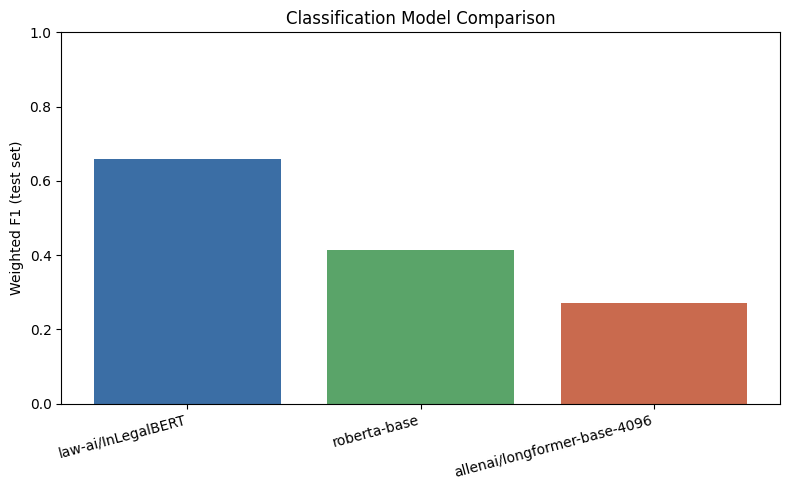


Best model by test weighted F1: law-ai/InLegalBERT (F1=0.6587)
This model is used for all downstream inference (predict_case / analyze_case).

--- Full classification report for law-ai/InLegalBERT ---
              precision    recall  f1-score   support

    Accepted       0.80      0.80      0.80        15
       Other       0.22      0.40      0.29         5
    Rejected       0.75      0.56      0.64        16

    accuracy                           0.64        36
   macro avg       0.59      0.59      0.58        36
weighted avg       0.70      0.64      0.66        36



In [ ]:
# ============================================================
# SECTION 13: COMPARISON TABLE + CHART, SELECT BEST MODEL
# ============================================================
comparison_rows = []
for name, res in all_results.items():
    comparison_rows.append({
        "Model": name,
        "Test Accuracy": round(res["test_accuracy"], 4),
        "Test Precision": round(res["test_precision"], 4),
        "Test Recall": round(res["test_recall"], 4),
        "Test F1": round(res["test_f1"], 4),
        "Best Val F1": round(res["best_val_f1"], 4) if res["best_val_f1"] else None,
        "Train Time (min)": round(res["train_time_sec"] / 60, 2),
    })
comparison_df = pd.DataFrame(comparison_rows).sort_values("Test F1", ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Test F1"], color=["#3b6ea5", "#5aa469", "#c96a4e"])
plt.ylim(0, 1)
plt.ylabel("Weighted F1 (test set)")
plt.title("Classification Model Comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

BEST_MODEL_NAME = comparison_df.iloc[0]["Model"]
best = all_results[BEST_MODEL_NAME]
print(f"\nBest model by test weighted F1: {BEST_MODEL_NAME} (F1={best['test_f1']:.4f})")
print("This model is used for all downstream inference (predict_case / analyze_case).")
print()
print(f"--- Full classification report for {BEST_MODEL_NAME} ---")
print(best["classification_report"])

# Promote the winning model's objects to the names the rest of the notebook expects
MODEL_NAME = BEST_MODEL_NAME
BEST_CFG = best["cfg"]
tokenizer = best["tokenizer"]
model = best["model"]
trainer = best["trainer"]
MAX_LEN = BEST_CFG["max_len"]
test_acc, test_precision, test_recall, test_f1 = (
    best["test_accuracy"], best["test_precision"], best["test_recall"], best["test_f1"]
)
test_preds, test_labels = best["test_preds"], best["test_labels"]
best_val_f1 = best["best_val_f1"]
training_time_sec = best["train_time_sec"]
history = best["log_history"]


## Section 14: Confusion Matrices for the Best Model (raw + normalized)

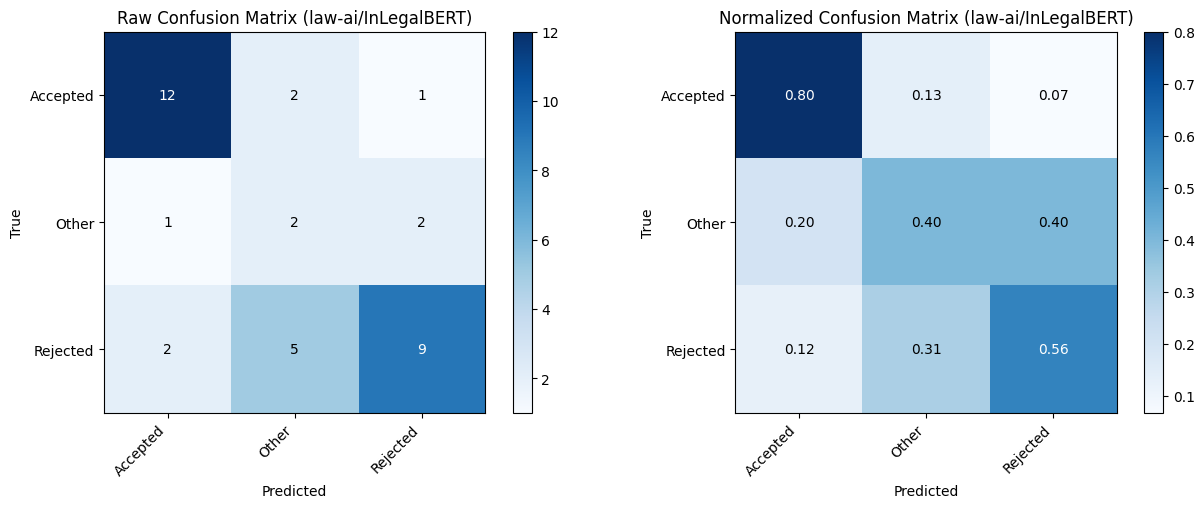

In [ ]:
# ============================================================
# SECTION 14: CONFUSION MATRICES (best model)
# ============================================================
cm_raw = confusion_matrix(test_labels, test_preds)
cm_norm = confusion_matrix(test_labels, test_preds, normalize="true")
class_names = list(label_mapping.values())

def plot_confusion(ax, cm, title, fmt):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text = f"{value:{fmt}}"
            color = "white" if value > thresh else "black"
            ax.text(j, i, text, ha="center", va="center", color=color)
    return im

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im1 = plot_confusion(axes[0], cm_raw, f"Raw Confusion Matrix ({MODEL_NAME})", "d")
fig.colorbar(im1, ax=axes[0])
im2 = plot_confusion(axes[1], cm_norm, f"Normalized Confusion Matrix ({MODEL_NAME})", ".2f")
fig.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()


## Section 15: Training Curves for the Best Model

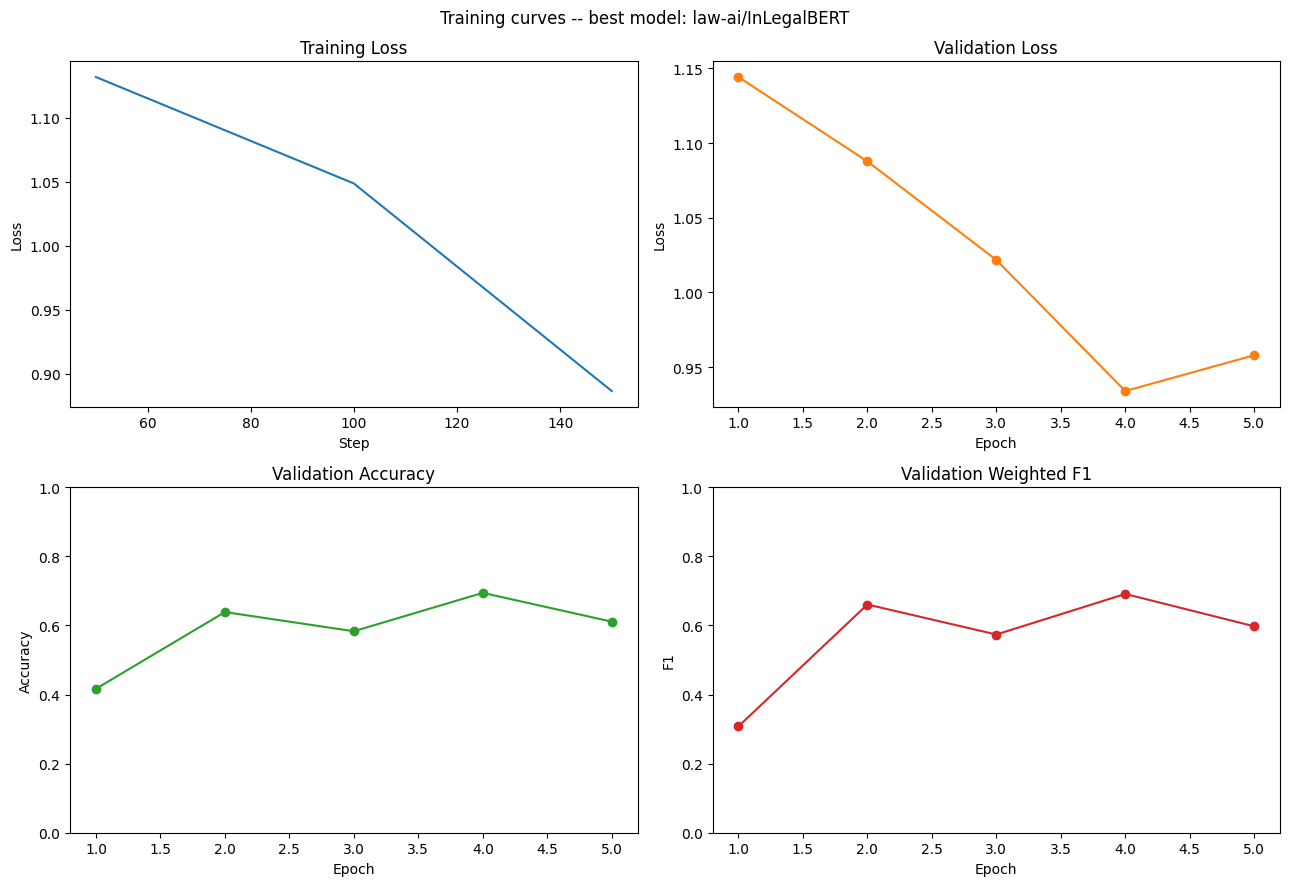

In [ ]:
# ============================================================
# SECTION 15: TRAINING CURVES (best model)
# ============================================================
train_loss = [(h["step"], h["loss"]) for h in history if "loss" in h]
eval_loss  = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]
eval_acc   = [(h["epoch"], h["eval_accuracy"]) for h in history if "eval_accuracy" in h]
eval_f1    = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

if train_loss:
    steps, losses = zip(*train_loss)
    axes[0, 0].plot(steps, losses, color="tab:blue")
axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Loss")

if eval_loss:
    epochs, losses = zip(*eval_loss)
    axes[0, 1].plot(epochs, losses, marker="o", color="tab:orange")
axes[0, 1].set_title("Validation Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")

if eval_acc:
    epochs, accs = zip(*eval_acc)
    axes[1, 0].plot(epochs, accs, marker="o", color="tab:green")
axes[1, 0].set_title("Validation Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_ylim(0, 1)

if eval_f1:
    epochs, f1s = zip(*eval_f1)
    axes[1, 1].plot(epochs, f1s, marker="o", color="tab:red")
axes[1, 1].set_title("Validation Weighted F1")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("F1")
axes[1, 1].set_ylim(0, 1)

plt.suptitle(f"Training curves -- best model: {MODEL_NAME}")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

with open("training_history.json", "w") as f:
    json.dump(history, f, indent=2)


## Section 16: Save Best Model, Tokenizer, Label Encoder

In [ ]:
# ============================================================
# SECTION 16: SAVE ARTIFACTS (best model only)
# ============================================================
SAVE_DIR = "./best_classification_model"
os.makedirs(SAVE_DIR, exist_ok=True)

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

with open(os.path.join(SAVE_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

with open(os.path.join(SAVE_DIR, "label_mapping.json"), "w") as f:
    json.dump(label_mapping, f, indent=2)

comparison_df.to_csv(os.path.join(SAVE_DIR, "model_comparison.csv"), index=False)

print("Saved best model:", MODEL_NAME)
print("Saved to:", SAVE_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best model: law-ai/InLegalBERT
Saved to: ./best_classification_model


## Section 20: Summarization Model (Legal-Pegasus, fallback T5-small)

In [ ]:
# ============================================================
# SECTION 20: SUMMARIZATION MODEL (long-context + map-reduce refine)
# ============================================================
# Changes vs. the previous version:
#   1. Primary model is now allenai/led-base-16384 (Longformer-Encoder-Decoder),
#      which natively handles up to 16,384 input tokens -- Indian judgments
#      routinely run 3,000-15,000+ words, so the old 1024-token PEGASUS/T5
#      truncation was silently discarding the ruling/holding on most inputs.
#   2. If a document still exceeds the loaded model's native context (or if
#      we fall back to legal-pegasus/t5-small, which are still 1024-token
#      models), we use a map-reduce "refine" pipeline instead of truncating:
#      split into overlapping, sentence-boundary-aware chunks -> summarize
#      each chunk ("map") -> summarize the concatenation of chunk summaries
#      ("reduce"/refine) into one coherent final summary. This makes the
#      pipeline length-robust regardless of which model actually loaded.
#   3. Added repetition_penalty + no_repeat_ngram_size to generation --
#      legal text is repetitive (boilerplate case citations, repeated party
#      names) and abstractive models tend to loop on it without this.

SUMM_PRIMARY = "allenai/led-base-16384"   # long-context: native 16k-token window, built for long documents
SUMM_SECONDARY = "nsi319/legal-pegasus"   # legal-domain PEGASUS; 1024-token window, used via chunked refine for long docs
SUMM_FALLBACK = "t5-small"                # lightweight last-resort fallback; also 1024-ish window, used via chunked refine

SUMM_MAX_INPUT_TOKENS = {
    "allenai/led-base-16384": 16384,
    "nsi319/legal-pegasus": 1024,
    "t5-small": 512,
}

def load_summarizer():
    for candidate in [SUMM_PRIMARY, SUMM_SECONDARY, SUMM_FALLBACK]:
        try:
            summ_tok = AutoTokenizer.from_pretrained(candidate)
            summ_model = AutoModelForSeq2SeqLM.from_pretrained(candidate)
            summ_model.to(device)

            # quick smoke test to catch OOM / load errors early
            smoke_len = min(1024, SUMM_MAX_INPUT_TOKENS[candidate])
            test_ids = summ_tok("test " * 50, return_tensors="pt", truncation=True, max_length=smoke_len).to(device)
            gen_kwargs = {}
            if candidate == "allenai/led-base-16384":
                # LED requires an explicit global attention mask; giving the
                # first token global attention is the standard LED setup.
                gam = torch.zeros_like(test_ids["input_ids"])
                gam[:, 0] = 1
                gen_kwargs["global_attention_mask"] = gam
            with torch.no_grad():
                summ_model.generate(**test_ids, max_new_tokens=10, **gen_kwargs)

            print(f"Loaded summarizer: {candidate}")
            return summ_tok, summ_model, candidate
        except Exception as e:
            print(f"Could not load {candidate} ({e}); trying next option...")
            torch.cuda.empty_cache()
    raise RuntimeError("No summarization model could be loaded -- check network/VRAM.")

summ_tokenizer, summ_model, SUMM_MODEL_NAME = load_summarizer()
SUMM_MODEL_MAX_TOKENS = SUMM_MAX_INPUT_TOKENS[SUMM_MODEL_NAME]
print("Using summarization model:", SUMM_MODEL_NAME, "| native context:", SUMM_MODEL_MAX_TOKENS, "tokens")


def _split_into_chunks(text, tokenizer, max_tokens, overlap_tokens=100):
    """Sentence-boundary-aware chunking so a chunk never cuts an argument or
    citation in half. `overlap_tokens` carries a bit of the previous chunk's
    tail into the next chunk so the refine step doesn't lose context at the
    seams."""
    sentences = re.split(r"(?<=[.!?])\s+", str(text).strip())
    chunks, current, current_len = [], [], 0
    for sent in sentences:
        sent_len = len(tokenizer.encode(sent, add_special_tokens=False))
        if current_len + sent_len > max_tokens and current:
            chunks.append(" ".join(current))
            overlap, overlap_len = [], 0
            for s in reversed(current):
                s_len = len(tokenizer.encode(s, add_special_tokens=False))
                if overlap_len + s_len > overlap_tokens:
                    break
                overlap.insert(0, s)
                overlap_len += s_len
            current, current_len = overlap, overlap_len
        current.append(sent)
        current_len += sent_len
    if current:
        chunks.append(" ".join(current))
    return chunks if chunks else [str(text)]


def _generate_summary(text, tok, model, model_name, max_input_tokens, max_summary_tokens, min_summary_tokens):
    prefix = "summarize: " if "t5" in model_name else ""
    inputs = tok(prefix + text, return_tensors="pt", truncation=True, max_length=max_input_tokens).to(device)
    gen_kwargs = dict(
        max_new_tokens=max_summary_tokens,
        min_new_tokens=max(min_summary_tokens, 1),
        num_beams=4,
        length_penalty=2.0,
        repetition_penalty=1.3,     # discourage repeating boilerplate legal phrases
        no_repeat_ngram_size=3,     # hard-block 3-gram loops
        early_stopping=True,
    )
    if model_name == "allenai/led-base-16384":
        global_attention_mask = torch.zeros_like(inputs["input_ids"])
        global_attention_mask[:, 0] = 1
        gen_kwargs["global_attention_mask"] = global_attention_mask
    with torch.no_grad():
        summary_ids = model.generate(**inputs, **gen_kwargs)
    return tok.decode(summary_ids[0], skip_special_tokens=True)


def summarize_case(text, max_summary_tokens=150, min_summary_tokens=40,
                    chunk_summary_tokens=100, refine=True):
    """
    Length-robust summarization:
      - If the document fits inside the loaded model's native context,
        summarize it directly (single pass).
      - Otherwise, run a map-reduce "refine" pass: chunk the document,
        summarize each chunk, then summarize the concatenation of chunk
        summaries into one final, coherent summary. This means summary
        quality no longer silently degrades on long judgments -- every
        part of the document contributes to the final summary instead of
        everything past the token limit being discarded.
    """
    text = str(text)
    total_tokens = len(summ_tokenizer.encode(text, add_special_tokens=False))
    original_len = len(text.split())

    if total_tokens <= SUMM_MODEL_MAX_TOKENS or not refine:
        summary = _generate_summary(text, summ_tokenizer, summ_model, SUMM_MODEL_NAME,
                                     SUMM_MODEL_MAX_TOKENS, max_summary_tokens, min_summary_tokens)
        method = "direct"
    else:
        chunks = _split_into_chunks(text, summ_tokenizer, SUMM_MODEL_MAX_TOKENS - 50)
        chunk_summaries = [
            _generate_summary(c, summ_tokenizer, summ_model, SUMM_MODEL_NAME,
                               SUMM_MODEL_MAX_TOKENS, chunk_summary_tokens, max(min_summary_tokens // 2, 1))
            for c in chunks
        ]
        combined = " ".join(chunk_summaries)
        summary = _generate_summary(combined, summ_tokenizer, summ_model, SUMM_MODEL_NAME,
                                     SUMM_MODEL_MAX_TOKENS, max_summary_tokens, min_summary_tokens)
        method = f"refine ({len(chunks)} chunks)"

    summary_len = len(summary.split())
    compression_ratio = round(summary_len / max(original_len, 1), 4)
    return {
        "summary": summary,
        "original_length": original_len,
        "summary_length": summary_len,
        "compression_ratio": compression_ratio,
        "method": method,
        "input_tokens": total_tokens,
    }


## Section 20b: Fine-Tune the Summarizer on Domain Data (recommended)

The pretrained LED/legal-pegasus/T5 models above have never seen an Indian court judgment written in your dataset's style. If real gold summaries exist in `case_info`, fine-tuning closes that domain gap and is the single biggest lever for summary quality -- this step is skipped automatically if no usable `case_info` reference summaries are found.

In [ ]:
# ============================================================
# SECTION 20b: FINE-TUNE THE SUMMARIZER ON DOMAIN DATA (optional, recommended)
# ============================================================
# Zero-shot pretrained summarizers (LED / legal-pegasus / T5) have never seen
# your judgments or your dataset's summary style. If real gold summaries are
# available in "case_info", fine-tune the currently loaded model on
# (judgement -> case_info) pairs before evaluating/using it.

FINE_TUNE_SUMMARIZER = True  # set False to skip and use the zero-shot model as-is

def _has_usable_case_info(frame):
    return (
        "case_info" in frame.columns
        and (frame["case_info"].astype(str).str.strip().str.len() > 0).mean() > 0.5
    )

if FINE_TUNE_SUMMARIZER and _has_usable_case_info(df):
    summ_train_df = df[df["case_info"].astype(str).str.strip().str.len() > 0].copy()
    summ_train_df, summ_val_df = train_test_split(summ_train_df, test_size=0.1, random_state=SEED)
    print(f"Fine-tuning {SUMM_MODEL_NAME} on {len(summ_train_df)} (judgement, case_info) pairs "
          f"({len(summ_val_df)} held out for validation)")

    class SummDataset(Dataset):
        def __init__(self, frame, tok, max_input_tokens, max_target_tokens=180):
            self.texts = frame["judgement_raw"].tolist()
            self.targets = frame["case_info"].astype(str).tolist()
            self.tok = tok
            self.max_input_tokens = max_input_tokens
            self.max_target_tokens = max_target_tokens

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            prefix = "summarize: " if "t5" in SUMM_MODEL_NAME else ""
            model_inputs = self.tok(
                prefix + self.texts[idx], truncation=True, max_length=self.max_input_tokens
            )
            labels = self.tok(
                self.targets[idx], truncation=True, max_length=self.max_target_tokens
            )
            model_inputs["labels"] = labels["input_ids"]
            return model_inputs

    # Cap the fine-tuning input length below the model's full native context --
    # e.g. LED's 16384 tokens is great for zero-shot inference on long docs, but
    # training at full length is very VRAM-heavy on a single T4. 4096 covers the
    # large majority of judgments while keeping training tractable; raise it if
    # you have more GPU budget.
    SUMM_FT_MAX_INPUT_TOKENS = min(SUMM_MODEL_MAX_TOKENS, 4096)

    summ_train_ds = SummDataset(summ_train_df, summ_tokenizer, SUMM_FT_MAX_INPUT_TOKENS)
    summ_val_ds = SummDataset(summ_val_df, summ_tokenizer, SUMM_FT_MAX_INPUT_TOKENS)
    summ_collator = DataCollatorForSeq2Seq(summ_tokenizer, model=summ_model)

    summ_training_args = Seq2SeqTrainingArguments(
        output_dir="./summarizer_finetune",
        per_device_train_batch_size=1,           # long-context models are memory-heavy; keep small
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=16,           # effective batch size 16 without the memory cost
        num_train_epochs=3,
        learning_rate=3e-5,
        predict_with_generate=True,
        generation_max_length=180,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        fp16=torch.cuda.is_available(),
        gradient_checkpointing=True,              # trade compute for memory -- needed for long-context fine-tuning
        logging_steps=50,
        report_to="none",
    )

    summ_trainer = Seq2SeqTrainer(
        model=summ_model,
        args=summ_training_args,
        train_dataset=summ_train_ds,
        eval_dataset=summ_val_ds,
        data_collator=summ_collator,
        tokenizer=summ_tokenizer,
    )

    summ_trainer.train()
    summ_model = summ_trainer.model  # summarize_case() picks up the fine-tuned weights via this global

    SUMM_FT_SAVE_DIR = "./best_summarization_model"
    import os as _os
    _os.makedirs(SUMM_FT_SAVE_DIR, exist_ok=True)
    summ_trainer.save_model(SUMM_FT_SAVE_DIR)
    summ_tokenizer.save_pretrained(SUMM_FT_SAVE_DIR)
    print("Summarizer fine-tuning complete. Saved to:", SUMM_FT_SAVE_DIR)
else:
    print("Skipping summarizer fine-tuning (no usable case_info reference summaries found, "
          "or FINE_TUNE_SUMMARIZER=False). Using the zero-shot pretrained model.")


## Section 21: Summarization Evaluation (ROUGE + BERTScore)

In [ ]:
# ============================================================
# SECTION 21: SUMMARIZATION EVALUATION (ROUGE + BERTScore)
# ============================================================
# Changes vs. the previous version:
#   - We no longer fall back to a lead-3-sentence extractive baseline as the
#     ROUGE reference. Lead-3 rewards copying the opening of the judgment and
#     *penalizes* a correct abstractive summary that jumps straight to the
#     ruling/holding -- exactly the behavior we want from a legal summarizer.
#     Instead we evaluate ONLY on rows with a real, populated "case_info"
#     gold summary, and explicitly report what fraction of the test set that
#     covers, so the numbers are honestly interpretable.
#   - Added BERTScore alongside ROUGE. ROUGE is pure lexical overlap and
#     under-credits correct paraphrases; BERTScore uses contextual embeddings
#     and better reflects semantic/factual similarity, which matters more for
#     legal summaries than exact wording does.
#   - summarize_case() now reports which method (direct vs. chunked refine)
#     was used per document, so we can see how much of the test set needed
#     the long-document refine path.

HAS_REFERENCE_SUMMARIES = _has_usable_case_info(df)
print("Usable case_info reference summaries found:", HAS_REFERENCE_SUMMARIES)

if not HAS_REFERENCE_SUMMARIES:
    print("*** No usable gold summaries in 'case_info' -- skipping ROUGE/BERTScore evaluation. ***")
    print("*** Add a populated 'case_info' or 'reference_summary' column to enable this section. ***")
    avg_rouge1 = avg_rouge2 = avg_rougeL = avg_bertscore_f1 = None
else:
    rouge_scorer_obj = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

    eval_rows = df[df["case_info"].astype(str).str.strip().str.len() > 0]
    eval_rows = eval_rows[eval_rows["judgement_clean"].isin(X_test)]
    coverage = len(eval_rows) / max(len(X_test), 1)
    print(f"Gold-summary coverage of test set: {len(eval_rows)}/{len(X_test)} ({coverage:.1%})")

    N_ROUGE_SAMPLES = min(100, len(eval_rows))  # cap for runtime; raise if you have GPU budget to spare
    eval_sample = eval_rows.sample(n=N_ROUGE_SAMPLES, random_state=SEED) if N_ROUGE_SAMPLES > 0 else eval_rows

    rouge1_scores, rouge2_scores, rougeL_scores = [], [], []
    references, candidates, methods_used = [], [], []

    for _, row in eval_sample.iterrows():
        reference = str(row["case_info"]).strip()
        result = summarize_case(row["judgement_raw"])
        candidate = result["summary"]
        scores = rouge_scorer_obj.score(reference, candidate)
        rouge1_scores.append(scores["rouge1"].fmeasure)
        rouge2_scores.append(scores["rouge2"].fmeasure)
        rougeL_scores.append(scores["rougeL"].fmeasure)
        references.append(reference)
        candidates.append(candidate)
        methods_used.append(result["method"])

    avg_rouge1 = float(np.mean(rouge1_scores)) if rouge1_scores else 0.0
    avg_rouge2 = float(np.mean(rouge2_scores)) if rouge2_scores else 0.0
    avg_rougeL = float(np.mean(rougeL_scores)) if rougeL_scores else 0.0

    print(f"Evaluated ROUGE on {len(rouge1_scores)} test samples")
    print(f"Average ROUGE-1 F1: {avg_rouge1:.4f}")
    print(f"Average ROUGE-2 F1: {avg_rouge2:.4f}")
    print(f"Average ROUGE-L F1: {avg_rougeL:.4f}")
    if methods_used:
        print("Summarization method breakdown:", pd.Series(methods_used).value_counts().to_dict())

    # BERTScore -- catches paraphrases/synonyms ROUGE's lexical overlap misses.
    try:
        from bert_score import score as bert_score_fn
        _, _, bertscore_f1 = bert_score_fn(candidates, references, lang="en", verbose=False)
        avg_bertscore_f1 = float(bertscore_f1.mean())
        print(f"Average BERTScore F1: {avg_bertscore_f1:.4f}")
    except Exception as e:
        print(f"BERTScore unavailable ({e}); install with `pip install bert-score`.")
        avg_bertscore_f1 = None

    plt.figure(figsize=(7, 4))
    metric_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L"] + (["BERTScore"] if avg_bertscore_f1 is not None else [])
    metric_vals = [avg_rouge1, avg_rouge2, avg_rougeL] + ([avg_bertscore_f1] if avg_bertscore_f1 is not None else [])
    plt.bar(metric_names, metric_vals, color="#3b6ea5")
    plt.ylim(0, 1)
    plt.title("Summarization Evaluation Scores")
    plt.ylabel("F1 Score")
    plt.tight_layout()
    plt.savefig("rouge_scores.png", dpi=150)
    plt.show()


## Section 21: Prediction Function

In [ ]:
# ============================================================
# SECTION 21: PREDICTION FUNCTION (uses the winning model from Section 13)
# ============================================================
model.eval()

def predict_case(text):
    cleaned = clean_text(text)
    enc = encode_for_classification(cleaned, tokenizer, BEST_CFG)
    enc = {k: torch.tensor([v]).to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    return {
        "predicted_label": label_mapping[pred_idx],
        "confidence": float(probs[pred_idx]),
        "probabilities": {label_mapping[i]: float(p) for i, p in enumerate(probs)},
    }


## Section 22: Full Pipeline

In [ ]:
# ============================================================
# SECTION 22: FULL PIPELINE (judgment -> summary -> classification)
# ============================================================
def analyze_case(text):
    summary_result = summarize_case(text)
    prediction_result = predict_case(text)
    return {
        "original_judgment": text,
        "generated_summary": summary_result["summary"],
        "compression_ratio": summary_result["compression_ratio"],
        "predicted_class": prediction_result["predicted_label"],
        "confidence_score": prediction_result["confidence"],
        "prediction_probability": prediction_result["probabilities"],
    }


## Section 23: Sample Inference on 3 Judgments

In [ ]:
# ============================================================
# SECTION 23: SAMPLE INFERENCE
# ============================================================
sample_indices = np.random.choice(len(X_test), size=min(3, len(X_test)), replace=False)

for i, idx in enumerate(sample_indices, 1):
    raw_text = df.loc[df["judgement_clean"] == X_test[idx], "judgement_raw"].values
    text_to_use = raw_text[0] if len(raw_text) else X_test[idx]
    result = analyze_case(text_to_use)
    print(f"--- Sample {i} ---")
    print("True label:", label_mapping[int(y_test[idx])])
    print("Predicted :", result["predicted_class"], f"(confidence {result['confidence_score']:.3f})")
    print("Summary   :", result["generated_summary"][:300], "...")
    print()


[transformers] Both `max_new_tokens` (=150) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=40) and `min_length`(=32) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=40) and `min_length`(=32) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

--- Sample 1 ---
True label: Rejected
Predicted : Rejected (confidence 0.647)
Summary   : The High Court has upheld the conviction of a man found guilty of murdering his neighbour with an axe. The trial court had acquitted the appellant of the charges under section 302 of the Indian Penal Code. The High Court has held that the trial judge had disbelieved the witnesses mainly on the bans  ...



[transformers] Both `max_new_tokens` (=150) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=40) and `min_length`(=32) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Sample 2 ---
True label: Other
Predicted : Other (confidence 0.410)
Summary   : The Supreme Court has quashed the orders of the committee of inquiry which had issued non-issue notices to three senior police officers to be cross-examined in the beginning and others at the end of the inquiry. The committee had issued the notices on the basis of which notices under section 8b of t ...

--- Sample 3 ---
True label: Rejected
Predicted : Accepted (confidence 0.362)
Summary   : The High Court of Jammu and Kashmir has dismissed a petition challenging the constitutional validity of the amendment to the Jammu and Kashmir Legislative Assembly Act, 1957. Section 47 of the Act provides that the legislative assembly shall consist of 111 members chosen by direct election from terr ...



## Section 24: Final Report

In [ ]:
# ============================================================
# SECTION 24: FINAL SUMMARY REPORT
# ============================================================
print("=" * 60)
print("FINAL REPORT")
print("=" * 60)
print(f"Dataset Size         : {len(df)}")
print(f"Number of Classes    : {NUM_CLASSES}")
print(f"Training Samples     : {len(X_train)}")
print(f"Validation Samples   : {len(X_val)}")
print(f"Testing Samples      : {len(X_test)}")
print(f"Best Validation F1   : {best_val_f1}")
print(f"Final Test Accuracy  : {test_acc:.4f}")
print(f"Final Test Precision : {test_precision:.4f}")
print(f"Final Test Recall    : {test_recall:.4f}")
print(f"Final Test F1        : {test_f1:.4f}")
print(f"Training Time (min)  : {training_time_sec/60:.2f}")
print(f"GPU Used             : {GPU_NAME}")
print(f"Classification Model : {MODEL_NAME}")
print(f"Summarization Model  : {SUMM_MODEL_NAME}")
print(f"ROUGE-1 F1 (summary)  : {avg_rouge1:.4f}")
print(f"ROUGE-2 F1 (summary)  : {avg_rouge2:.4f}")
print(f"ROUGE-L F1 (summary)  : {avg_rougeL:.4f}")
print("=" * 60)
print()
print("Full classification model comparison (all three, sorted by test F1):")
print(comparison_df.to_string(index=False))
print("=" * 60)


FINAL REPORT
Dataset Size         : 360
Number of Classes    : 3
Training Samples     : 288
Validation Samples   : 36
Testing Samples      : 36
Best Validation F1   : 0.6913222724987431
Final Test Accuracy  : 0.6389
Final Test Precision : 0.6975
Final Test Recall    : 0.6389
Final Test F1        : 0.6587
Training Time (min)  : 2.07
GPU Used             : Tesla T4
Classification Model : law-ai/InLegalBERT
Summarization Model  : nsi319/legal-pegasus
ROUGE-1 F1 (summary)  : 0.0907
ROUGE-2 F1 (summary)  : 0.0309
ROUGE-L F1 (summary)  : 0.0685

Full classification model comparison (all three, sorted by test F1):
                       Model  Test Accuracy  Test Precision  Test Recall  Test F1  Best Val F1  Train Time (min)
          law-ai/InLegalBERT         0.6389          0.6975       0.6389   0.6587       0.6913              2.07
                roberta-base         0.4167          0.5028       0.4167   0.4140       0.6419              2.06
allenai/longformer-base-4096         0.3056   